In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [3]:
df = pd.read_csv("bank-full.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [5]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [7]:
balance_yes = df[df["y"] == "yes"]["balance"]
balance_no = df[df["y"] == "no"]["balance"]

print("Subscribed customers:", len(balance_yes))
print("Non-subscribed customers:", len(balance_no))

Subscribed customers: 5289
Non-subscribed customers: 39922


In [8]:
print("Average balance of subscribed customers:",
      balance_yes.mean())

print("Average balance of non-subscribed customers:",
      balance_no.mean())

Average balance of subscribed customers: 1804.2679145396105
Average balance of non-subscribed customers: 1303.7149691899203


In [9]:
print("Standard deviation - subscribed:",
      balance_yes.std())

print("Standard deviation - non-subscribed:",
      balance_no.std())

Standard deviation - subscribed: 3501.104776507358
Standard deviation - non-subscribed: 2974.1954729633367


In [10]:
summary = pd.DataFrame({
    "Group": ["Subscribed", "Not Subscribed"],
    "Count": [balance_yes.count(), balance_no.count()],
    "Mean Balance": [balance_yes.mean(), balance_no.mean()],
    "Standard Deviation": [balance_yes.std(), balance_no.std()]
})

summary

,Group,Count,Mean Balance,Standard Deviation
0,Subscribed,5289,1804.267915,3501.104777
1,Not Subscribed,39922,1303.714969,2974.195473


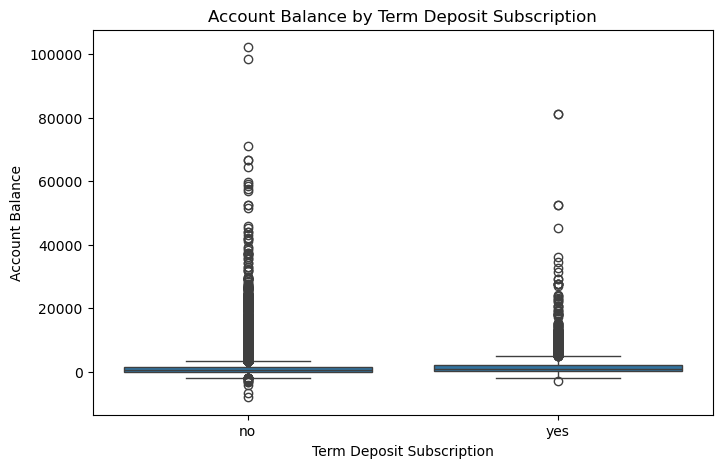

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="y", y="balance", data=df)

plt.title("Account Balance by Term Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Account Balance")

plt.show()

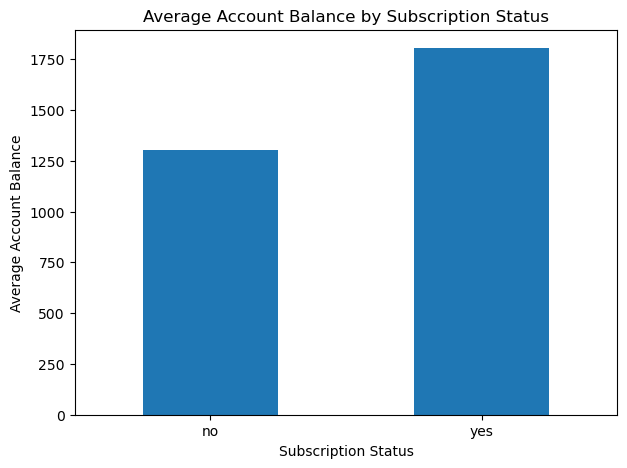

In [12]:
average_balance = df.groupby("y")["balance"].mean()

plt.figure(figsize=(7, 5))

average_balance.plot(kind="bar")

plt.title("Average Account Balance by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Account Balance")

plt.xticks(rotation=0)

plt.show()

In [13]:
t_stat, p_value = ttest_ind(
    balance_yes,
    balance_no,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 9.933545392962255
P-value: 4.3837327771001536e-23


In [14]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average balance.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average balance.")

Reject the null hypothesis.
There is a statistically significant difference in average balance.


In [15]:
mean_yes = balance_yes.mean()
mean_no = balance_no.mean()

difference = mean_yes - mean_no

print("Mean balance - subscribed:", mean_yes)
print("Mean balance - not subscribed:", mean_no)
print("Difference in means:", difference)

Mean balance - subscribed: 1804.2679145396105
Mean balance - not subscribed: 1303.7149691899203
Difference in means: 500.55294534969016


In [16]:
print("----- Hypothesis Testing Result -----")
print("Null Hypothesis: Average balance is the same for both groups.")
print("Alternative Hypothesis: Average balance differs between the groups.")
print("Significance Level:", alpha)
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("\nConclusion: Reject H0.")
    print("There is a statistically significant difference in average account balance between subscribed and non-subscribed customers.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("There is not enough statistical evidence to conclude that the average account balance differs between subscribed and non-subscribed customers.")

----- Hypothesis Testing Result -----
Null Hypothesis: Average balance is the same for both groups.
Alternative Hypothesis: Average balance differs between the groups.
Significance Level: 0.05
T-statistic: 9.933545392962255
P-value: 4.3837327771001536e-23

Conclusion: Reject H0.
There is a statistically significant difference in average account balance between subscribed and non-subscribed customers.
